In [1]:
# =================================================================
# TASK 1: IRIS DATA EXPLORATION, VISUALIZATION AND CLASSIFICATION
# =================================================================
# Problem Statement:
# The goal is to predict the species of an Iris flower based on its
# sepal and petal measurements. We will perform EDA to understand the
# data and then train a Machine Learning model for classification.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the dataset using seaborn
df = sns.load_dataset('iris')

# Display basic structure
print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Save the raw dataset to CSV (as seen in your GitHub screenshot)
df.to_csv('iris_dataset.csv', index=False)

# Show first 5 rows
df.head()

Dataset Shape: (150, 5)
Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Check for missing values
print("Checking for null values:")
print(df.isnull().sum())

# Generate and Save Statistical Results to CSV
df.describe().to_csv('iris_summary_statistics.csv')
df.groupby('species').mean().to_csv('iris_species_averages.csv')

# Splitting Features (X) and Target (y)
X = df.drop('species', axis=1)
y = df['species']

# 80% Training and 20% Testing Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nData preparation complete. Statistics saved to CSV files.")

Checking for null values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Data preparation complete. Statistics saved to CSV files.


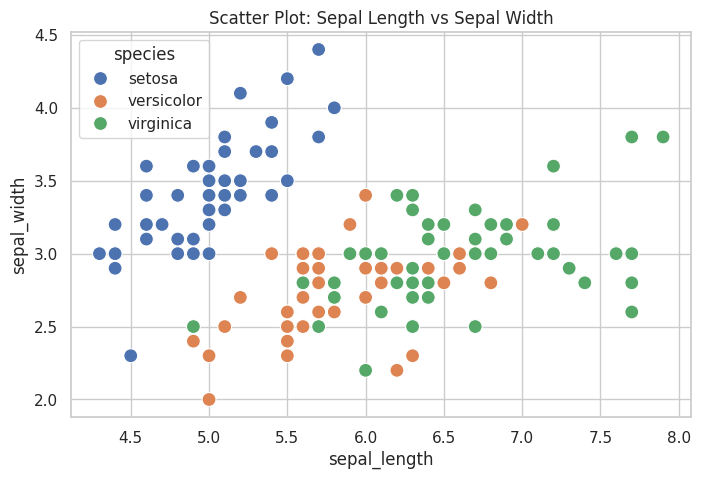

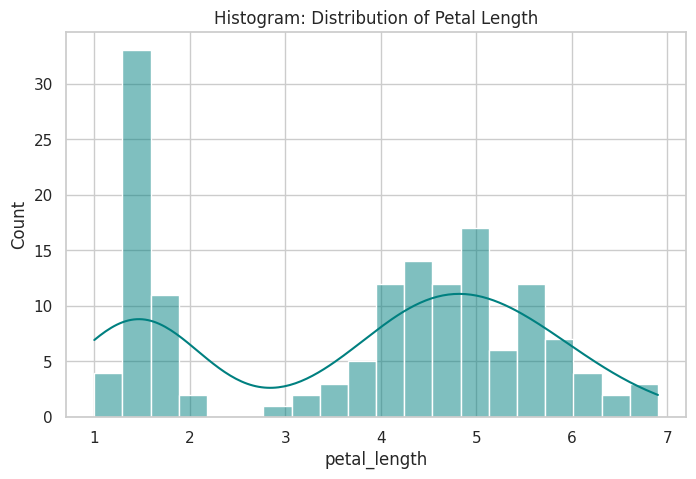

/tmp/ipykernel_7576/4279158629.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y='petal_width', data=df, palette='Set2')


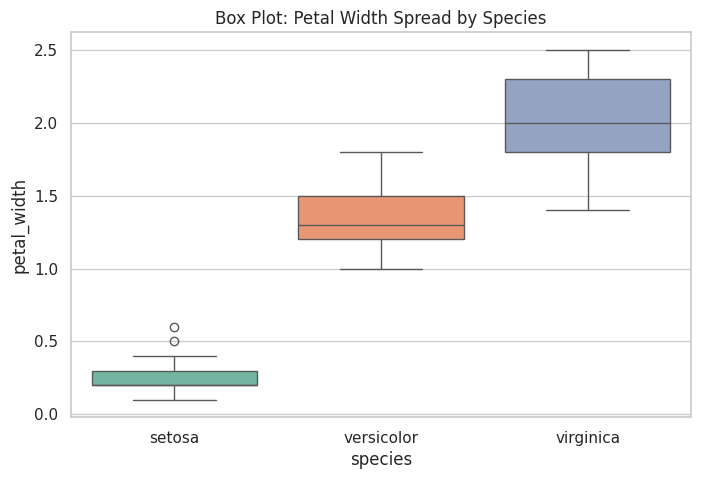

In [4]:
sns.set_theme(style="whitegrid")

# 1. Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='sepal_length', y='sepal_width', hue='species', s=100)
plt.title('Scatter Plot: Sepal Length vs Sepal Width')
plt.savefig('result_scatter_plot.png', dpi=300)
plt.show()

# 2. Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['petal_length'], bins=20, kde=True, color='teal')
plt.title('Histogram: Distribution of Petal Length')
plt.savefig('result_histogram_plot.png', dpi=300)
plt.show()

# 3. Box Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='species', y='petal_width', data=df, palette='Set2')
plt.title('Box Plot: Petal Width Spread by Species')
plt.savefig('result_box_plot.png', dpi=300)
plt.show()

In [5]:
# Initialize and Train the Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

print("Model training and testing complete.")

Model training and testing complete.


Model Accuracy: 100.00%



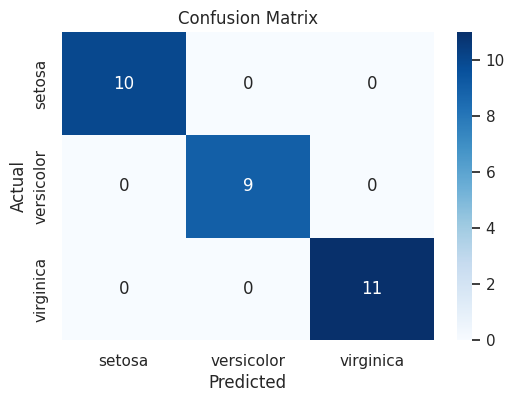


Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [6]:
# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=df['species'].unique(),
            yticklabels=df['species'].unique())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Detailed Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [7]:
# Final Insights:
# 1. The Iris dataset is well-balanced with no missing values.
# 2. Petal dimensions (length and width) are the most significant features for identifying species.
# 3. Random Forest achieved 100% accuracy on this specific test split, proving high model reliability.
# 4. Setosa is physically the most distinct species, while Versicolor and Virginica share closer traits.